In [20]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import NeutrinoGravNetNodesFaser
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import evaluate_gravnet_model_nodes
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

# Main

In [8]:
model = "gravnet_nodes_faser"
weights_path = get_weights_path() / f"{model}/best_model.pt"
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

In [5]:
# Test dataset
# data_path = get_torch_path() / "pointnetpp/test_dataset.pt"
# test_dataset = torch.load(data_path)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

In [29]:
# We create the datasets only once (but stored them in the pointnetpp directory)
data_model = "pointnetpp_faser"
torch_path = get_torch_path()
nue_path = torch_path / f"10000/{data_model}"
num_path = torch_path / f"10001/{data_model}"
nun_path = torch_path / f"10003/{data_model}"

num_events = 500
nue_dataset = torch.load(nue_path / "nue.pt", weights_only=False)[:num_events]
nue_truth_df = pd.read_parquet(nue_path / "nue_truth.parq")[:num_events]
num_dataset = torch.load(num_path / "num.pt", weights_only=False)[:num_events]
num_truth_df = pd.read_parquet(num_path / "num_truth.parq")[:num_events]
nun_dataset = torch.load(nun_path / "nun.pt", weights_only=False)[:num_events]
nun_truth_df = pd.read_parquet(nun_path / "nun_truth.parq")[:num_events]
dataset = nue_dataset + num_dataset + nun_dataset
truth_df = pd.concat([nue_truth_df, num_truth_df, nun_truth_df], ignore_index=True)

In [30]:
n_truth = len(truth_df)
n_dataset = len(dataset)
if n_truth != n_dataset:
    raise ValueError(
        f"Length of truth_df ({n_truth}) and dataset ({n_dataset}) do not match!"
    )

In [31]:
device = get_device("cpu")

model = NeutrinoGravNetNodesFaser(
    input_dim=dataset[0].x.shape[1],
    num_node_classes=len(hits),
    faser_dim=dataset[0].x_faser.shape[0],
)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [32]:
data_loader = DataLoader(dataset)
y_true, y_pred, y_prob = evaluate_gravnet_model_nodes(
    model=model,
    test_loader=data_loader,
    device=device,
    use_faser=True,
    # model=model, test_loader=test_loader, device=device
)

Evaluating: 100%|██████████| 1500/1500 [03:17<00:00,  7.60it/s]


In [33]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[hit.label for hit in hits]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

other: 72.2%
e: 78.7%
mu: 70.1%
average: 73.7%


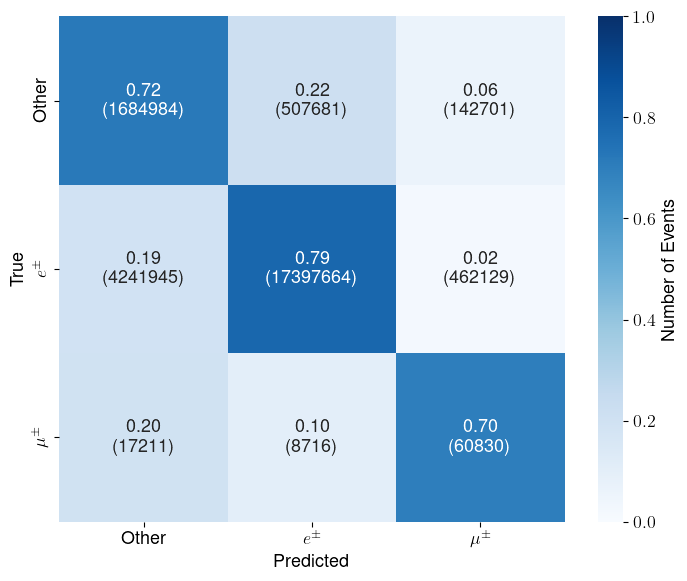

In [34]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[hit.latex_name for hit in hits]
)

/Users/tboeckh/Documents/faser/neutrino-detector/analysis/src/analysis/utils/validation_utils.py:166: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


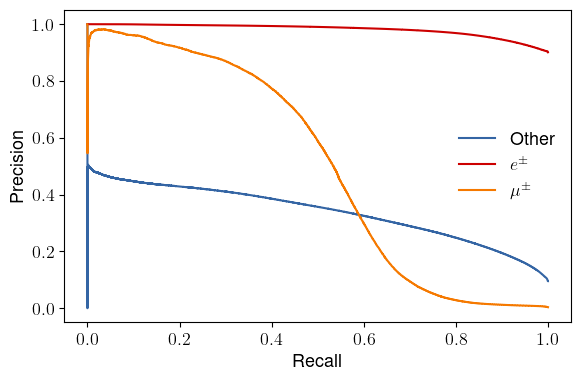

In [35]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[hit.latex_name for hit in hits]
)

/Users/tboeckh/Documents/faser/neutrino-detector/analysis/src/analysis/utils/validation_utils.py:136: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


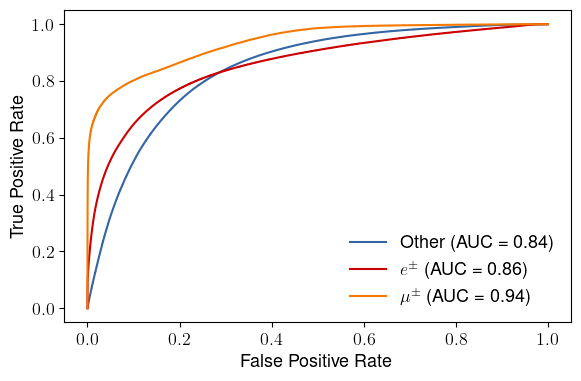

In [36]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[hit.latex_name for hit in hits],
    figure_path=figures_path / "roc_curve.png",
)

2335366.0
2335366.0
2335366.0


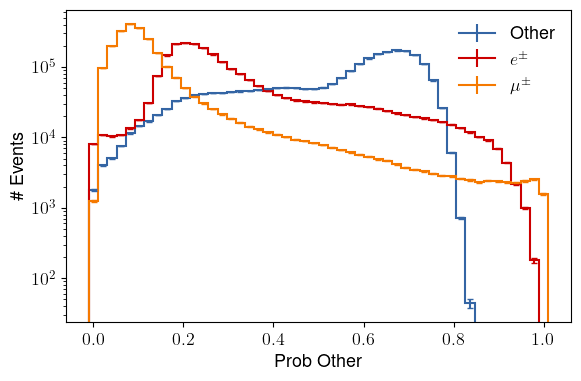

22101738.0
22101738.0
22101738.0


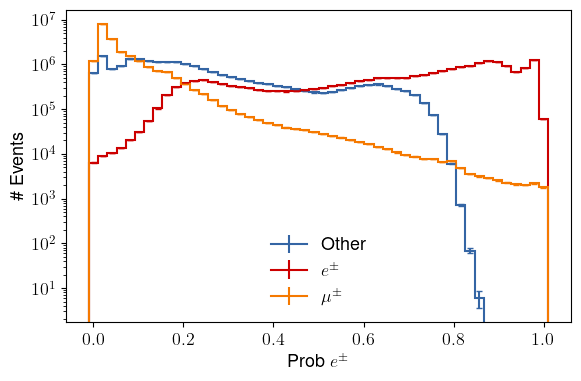

86757.0
86757.0
86757.0


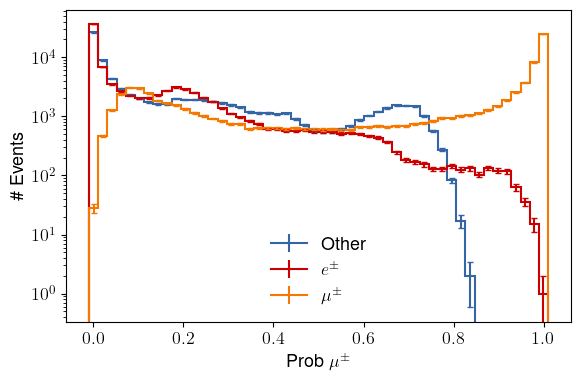

In [37]:
plot_probabilities(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[hit.latex_name for hit in hits],
    yscale="log",
)